# 02 - Statistical Diagnostics


In [1]:
import sys
sys.path.insert(0, '../Src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from stat_test import correlation_matrix, compute_vif, stationarity_summary, rolling_stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# Load aligned panel (bias-free, monthly, no transformations)
panel = pd.read_csv('../Data/Processed/aligned_panel.csv', index_col='date', parse_dates=True)
print(f"Panel shape: {panel.shape}, Date range: {panel.index.min().date()} to {panel.index.max().date()}")

Panel shape: (118, 16), Date range: 2016-01-31 to 2025-11-30


---
## 2.1 Checking Data



In [2]:
print(f"Missing values: {panel.isnull().sum().sum()}")
print(f"Frequency check (days between obs): {panel.index.to_series().diff().dt.days.median():.0f} days")
panel.head()

Missing values: 0
Frequency check (days between obs): 31 days


,y1,y2,y5,y10,y20,y30,cpi,indpro,unrate,fedfunds,m2,baa,aaa,baa10y,vix,sp500
date,,,,,,,,,,,,,,,,
2016-01-31,0.47,0.76,1.33,1.94,2.36,2.75,237.652,99.5607,4.8,0.34,12505.5,5.45,4.00,3.48,20.20,1940.24
2016-02-29,0.62,0.78,1.22,1.74,2.19,2.61,237.336,99.0445,4.9,0.38,12577.7,5.34,3.96,3.55,20.55,1932.23
2016-03-31,0.59,0.73,1.21,1.78,2.20,2.61,238.080,98.3096,5.0,0.36,12628.6,5.13,3.82,3.12,13.95,2059.74
2016-04-30,0.56,0.77,1.28,1.83,2.26,2.66,238.992,98.6421,5.1,0.37,12707.6,4.79,3.62,2.86,15.70,2065.30
2016-05-31,0.68,0.87,1.37,1.84,2.23,2.64,239.557,98.4184,4.8,0.37,12774.6,4.68,3.65,2.84,14.19,2096.96


---
## 2.2 Yield Curve Diagnostics (Term Structure Reality)
### Cross-Maturity Correlation Matrix


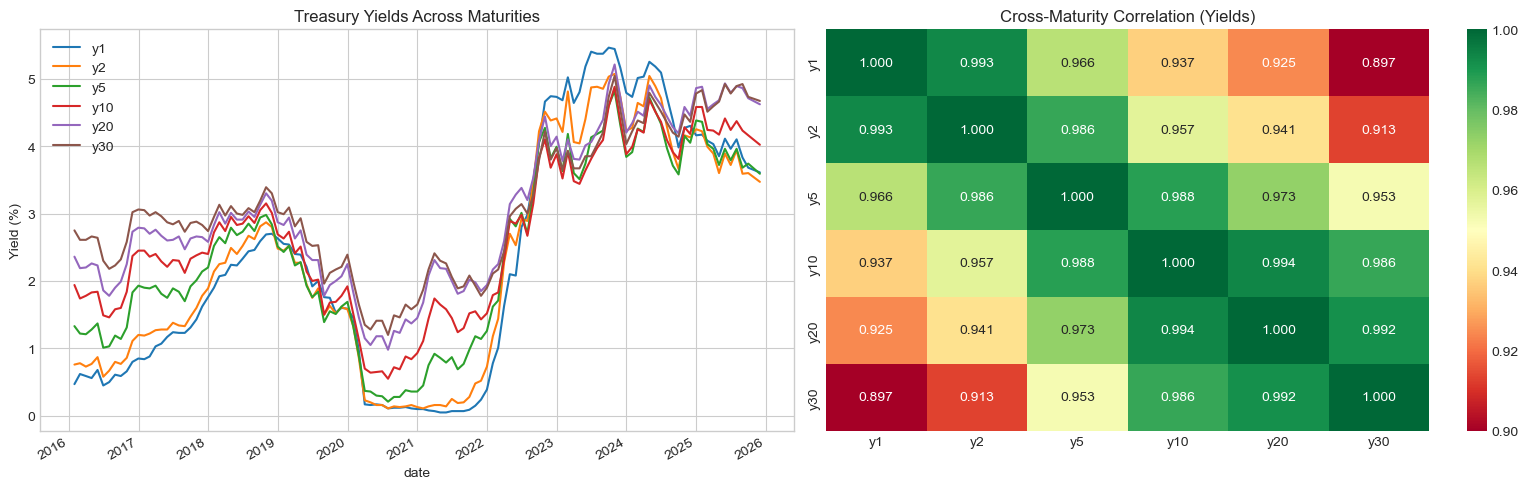

In [3]:
yields = panel[['y1', 'y2', 'y5', 'y10', 'y20', 'y30']]
yield_corr = correlation_matrix(yields)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
yields.plot(ax=axes[0], title='Treasury Yields Across Maturities')
axes[0].set_ylabel('Yield (%)')
sns.heatmap(yield_corr, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[1], vmin=0.9, vmax=1)
axes[1].set_title('Cross-Maturity Correlation (Yields)')
plt.tight_layout(); plt.show()

### Interpretation: Term Structure
- Correlations between maturities are **extremely high** (>0.95 for adjacent maturities)
- The yield curve is a **joint object**, not independent targets
- This justifies using **attention across maturities** to capture co-movement
- Standard multivariate regression would face **severe ill-conditioning**

---
## 2.3 Multicollinearity Diagnostics (The Big Claim)
**Claim**: "Handling multicollinearity from 10+ state variables"

**Proof**: VIF > 10 indicates problematic multicollinearity.

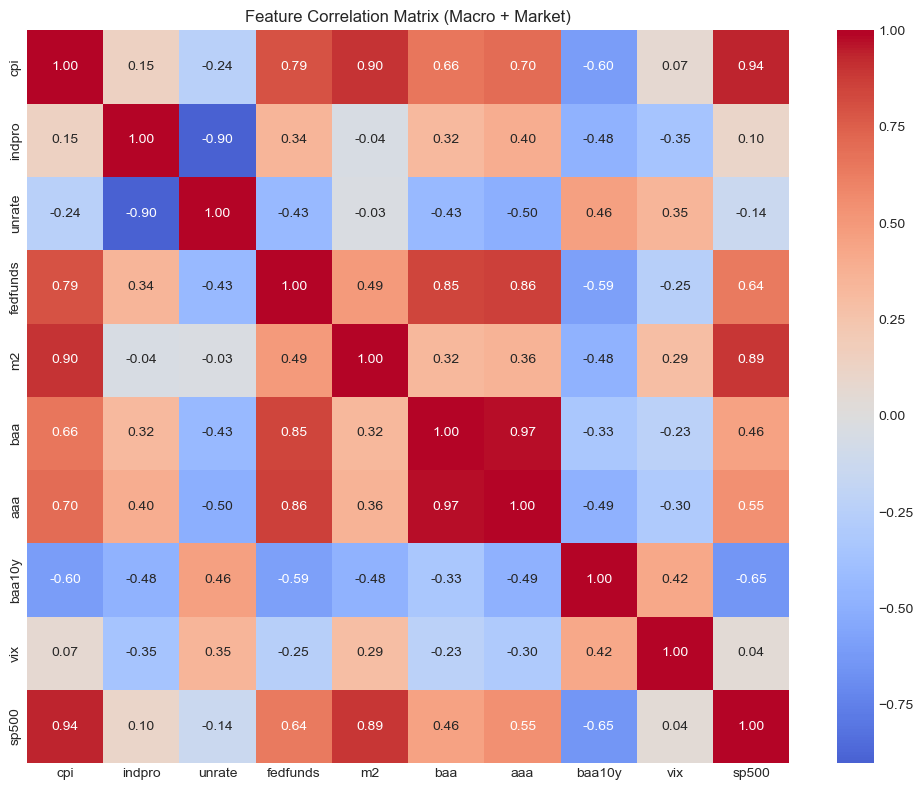

In [4]:
# Macro + market features only (exclude yield targets)
features = panel.drop(columns=['y1', 'y2', 'y5', 'y10', 'y20', 'y30'])
feature_corr = correlation_matrix(features)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(feature_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0)
ax.set_title('Feature Correlation Matrix (Macro + Market)')
plt.tight_layout(); plt.show()


Variance Inflation Factors (VIF > 10 = multicollinearity problem):
 feature         VIF
     cpi 8944.135752
     baa 2922.387412
     aaa 2203.921562
  indpro 2055.677420
      m2 1045.679644
   sp500  180.335597
  baa10y  166.314379
fedfunds   37.992720
  unrate   22.838684
     vix   17.753346


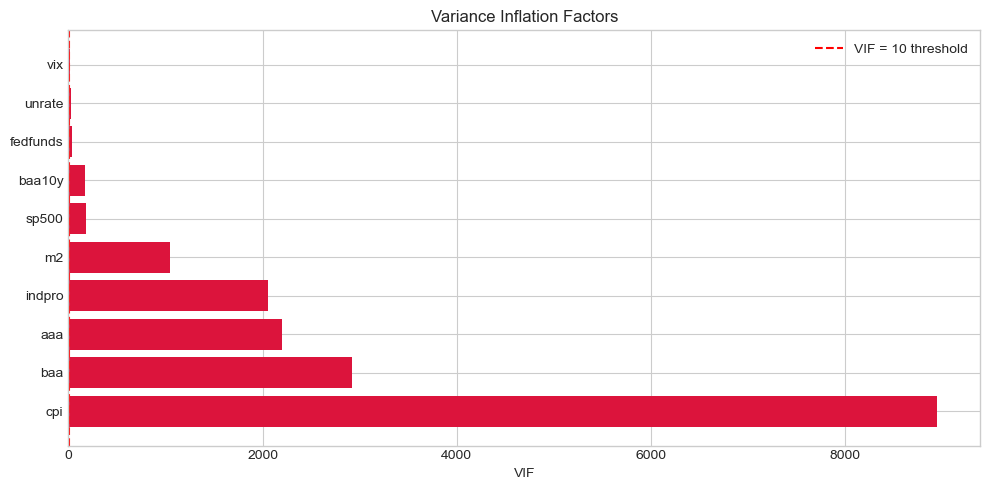

In [5]:
# VIF Analysis
vif_table = compute_vif(features)
print("\nVariance Inflation Factors (VIF > 10 = multicollinearity problem):")
print(vif_table.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(vif_table['feature'], vif_table['VIF'], color=['crimson' if v > 10 else 'steelblue' for v in vif_table['VIF']])
ax.axvline(10, color='red', linestyle='--', label='VIF = 10 threshold')
ax.set_xlabel('VIF'); ax.set_title('Variance Inflation Factors'); ax.legend()
plt.tight_layout(); plt.show()

### Interpretation: Multicollinearity
- **Multiple VIF values > 10** confirm severe multicollinearity in macro state space
- CPI, M2, and Industrial Production are highly correlated (inflation-output nexus)
- **OLS coefficients would be wildly unstable** â€” small data changes â†’ large coefficient swings
- This motivates:
  1. **Shrinkage methods** (Ridge, Lasso) as baselines
  2. **Neural Parameterized Expectations** that learn robust mappings
  3. **Attention mechanisms** to weight relevant features dynamically

---
## 2.4 Stationarity & Persistence (Finance Reality)

In [ ]:
stationarity = stationarity_summary(panel)
stationarity['stationary_label'] = stationarity['stationary'].map({True: 'âœ“ Stationary', False: 'âœ— Non-stationary'})
print("\nAugmented Dickey-Fuller Stationarity Tests:")
print(stationarity[['variable', 'adf_stat', 'p_value', 'stationary_label']].to_string(index=False))

# Count
n_stationary = stationarity['stationary'].sum()
n_total = len(stationarity)
print(f"\nSummary: {n_stationary}/{n_total} variables stationary at 5% level")


Augmented Dickey-Fuller Stationarity Tests:
variable  adf_stat  p_value   stationary_label
      y1 -1.372435 0.595418 âœ— Non-stationary
      y2 -2.560129 0.101521 âœ— Non-stationary
      y5 -1.016942 0.747035 âœ— Non-stationary
     y10 -0.896205 0.789220 âœ— Non-stationary
     y20 -0.687926 0.849852 âœ— Non-stationary
     y30 -0.655230 0.858008 âœ— Non-stationary
     cpi -0.085436 0.950870 âœ— Non-stationary
  indpro -2.989371 0.035899     âœ“ Stationary
  unrate -3.320883 0.013970     âœ“ Stationary
fedfunds -1.868884 0.346838 âœ— Non-stationary
      m2 -0.851053 0.803664 âœ— Non-stationary
     baa -1.166780 0.687720 âœ— Non-stationary
     aaa -0.690089 0.849300 âœ— Non-stationary
  baa10y -3.472292 0.008728     âœ“ Stationary
     vix -4.545949 0.000162     âœ“ Stationary
   sp500  0.749363 0.990773 âœ— Non-stationary

Summary: 4/16 variables stationary at 5% level


### Interpretation: Stationarity
- **Most macro variables are non-stationary** (CPI, M2, Industrial Production)
- **Long-maturity yields show high persistence** (low ADF stats, high p-values)

---
## 2.5 Regime Instability (Pre-Adversarial Evidence)

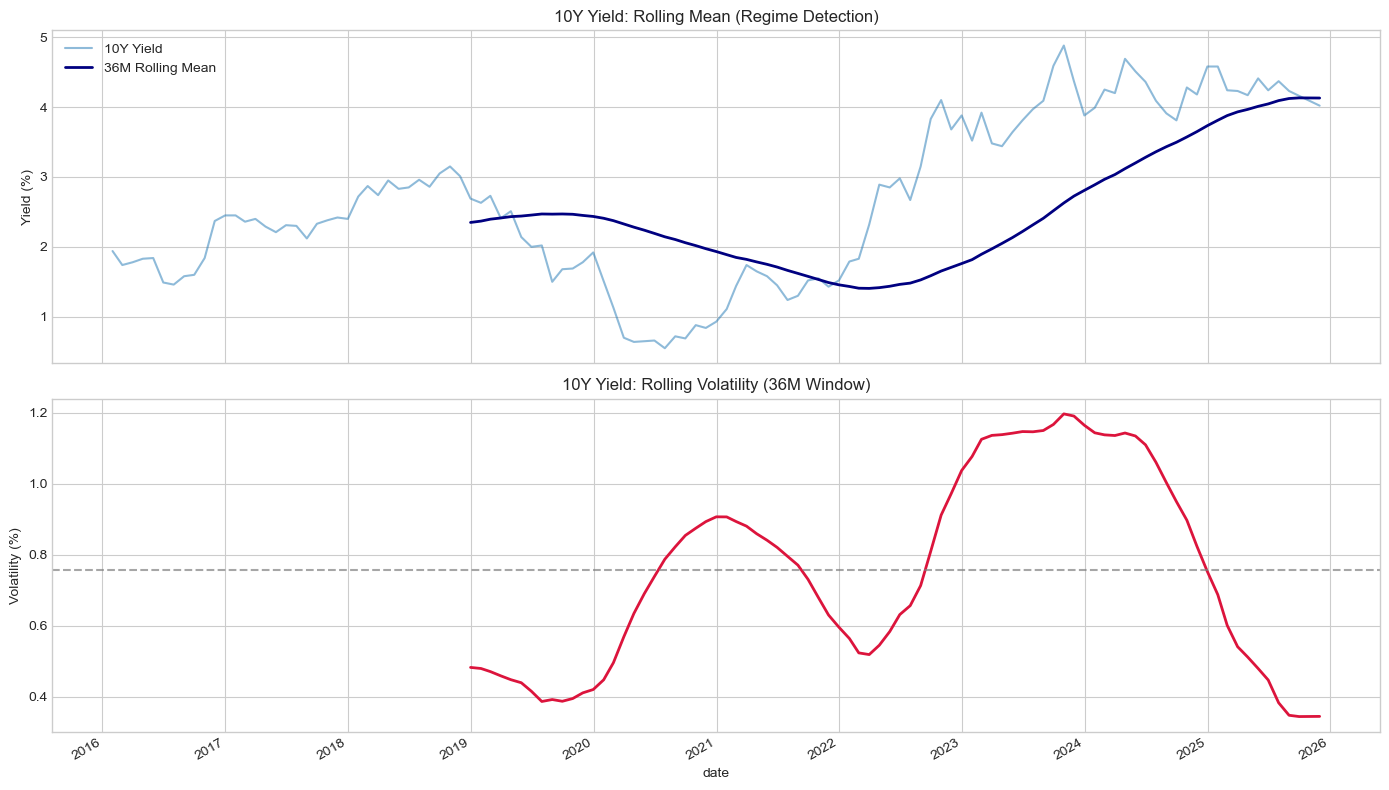

In [7]:
# Rolling statistics for 10Y yield (36-month window)
y10_rolling = rolling_stats(panel['y10'], window=36)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
panel['y10'].plot(ax=axes[0], alpha=0.5, label='10Y Yield')
y10_rolling['rolling_mean'].plot(ax=axes[0], color='navy', linewidth=2, label='36M Rolling Mean')
axes[0].set_ylabel('Yield (%)'); axes[0].legend(); axes[0].set_title('10Y Yield: Rolling Mean (Regime Detection)')

y10_rolling['rolling_std'].plot(ax=axes[1], color='crimson', linewidth=2)
axes[1].set_ylabel('Volatility (%)'); axes[1].set_title('10Y Yield: Rolling Volatility (36M Window)')
axes[1].axhline(y10_rolling['rolling_std'].mean(), color='gray', linestyle='--', alpha=0.7)
plt.tight_layout(); plt.show()

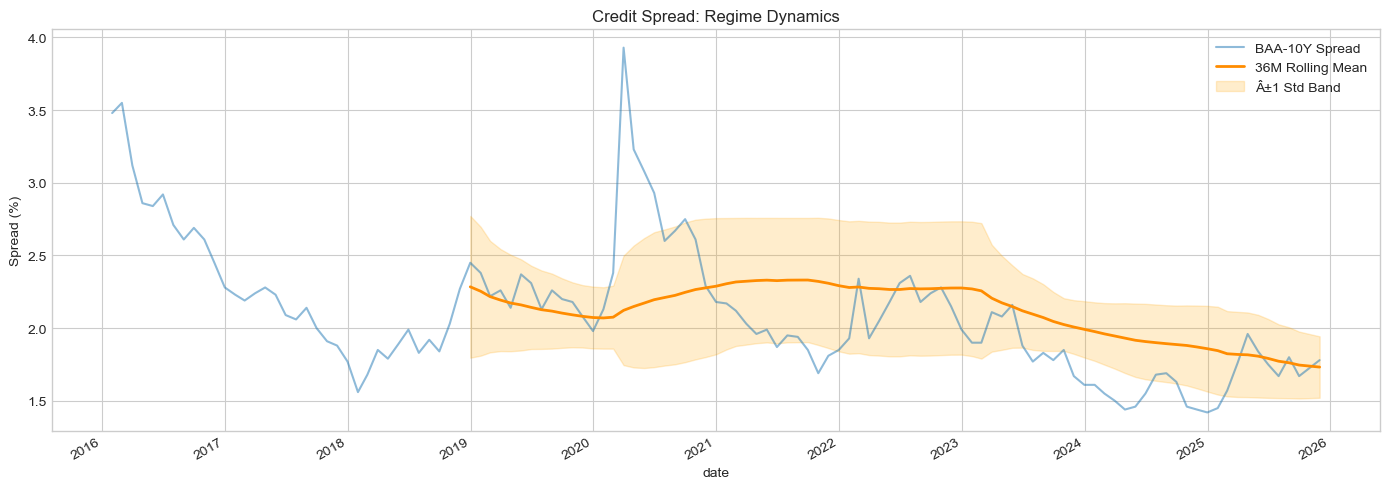

In [8]:
# Credit spread regime dynamics
baa_rolling = rolling_stats(panel['baa10y'], window=36)

fig, ax = plt.subplots(figsize=(14, 5))
panel['baa10y'].plot(ax=ax, alpha=0.5, label='BAA-10Y Spread')
baa_rolling['rolling_mean'].plot(ax=ax, color='darkorange', linewidth=2, label='36M Rolling Mean')
ax.fill_between(baa_rolling.index, 
                baa_rolling['rolling_mean'] - baa_rolling['rolling_std'],
                baa_rolling['rolling_mean'] + baa_rolling['rolling_std'], 
                alpha=0.2, color='orange', label='Â±1 Std Band')
ax.set_ylabel('Spread (%)'); ax.legend(); ax.set_title('Credit Spread: Regime Dynamics')
plt.tight_layout(); plt.show()

### Interpretation: Regime Instability
- **Clear volatility spikes** during crisis periods (COVID, rate hike cycle)
- **Mean shifts** across policy regimes.
- **Credit spreads show dramatic regime changes** â€” widening during stress
- This is **hard evidence for adversarial validation**:
  - Train/test splits that ignore regimes will overstate performance
  - We need **regime-aware temporal splits** for evaluation